# Computer Vision Masterclass - Face recognition


## OpenCV


### Loading the dataset

- Yale faces database: http://vision.ucsd.edu/content/yale-face-database


In [1]:
import cv2
import numpy as np
from google.colab import drive
from google.colab.patches import cv2_imshow
from PIL import Image

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

path = '/content/drive/MyDrive/Computer-Vision/Datasets/yalefaces.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

### Pre-processing the images


In [3]:
import os

print(len(os.listdir('/content/yalefaces/train')))

135


In [4]:
def get_image_data():
    paths = [os.path.join('/content/yalefaces/train', f)
             for f in os.listdir('/content/yalefaces/train')]

    faces = []
    ids = []
    for path in paths:
        image = Image.open(path).convert('L')  # Grayscale (L)
        image_np = np.array(image, 'uint8')

        id = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

        ids.append(id)
        faces.append(image_np)

    return np.array(ids), faces

In [5]:
ids, faces = get_image_data()

In [6]:
ids

array([11,  5, 15,  6,  7, 10, 14,  8, 12, 11,  7,  1,  8,  3, 12, 10,  7,
        3,  1,  4,  2, 13, 11,  7,  9,  2, 10, 15, 11, 13,  9, 10,  9, 12,
        4,  9, 12,  3,  6,  1, 13,  5,  1,  2,  2, 14,  7,  4,  6, 10,  4,
        3,  4, 11, 12, 14, 12, 15, 14,  5, 15, 15,  3, 11, 10, 13,  6,  3,
        4,  8, 13, 14,  1,  8,  1,  6, 15, 11, 12, 11,  4, 12,  2,  5,  8,
        8,  6, 10,  5,  6,  9,  7,  9, 12,  2, 15, 14,  1, 14, 13,  1,  3,
        6,  9,  7,  8,  6,  9, 11, 14, 13, 13,  8,  8,  1,  2,  5,  5,  9,
       15,  5,  2,  7,  3,  4,  4, 14,  7, 10,  2, 15, 10,  3, 13,  5])

In [7]:
len(ids)

135

In [8]:
len(faces)

135

In [9]:
faces[0], faces[0].shape

(array([[105, 103, 109, ..., 255, 255, 255],
        [230, 228, 237, ..., 255, 255, 255],
        [224, 227, 238, ..., 255, 255, 255],
        ...,
        [ 68,  69,  69, ..., 126, 114, 103],
        [ 65,  66,  66, ..., 126, 114, 103],
        [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8),
 (243, 320))

In [10]:
243 * 320

77760

### Training the LBPH classifier


In [11]:
# threshold: 1.7976931348623157e+308
# radius: 1
# neighbors: 8
# grid_x: 8
# grid_y: 8

lbph_classifier = cv2.face.LBPHFaceRecognizer_create(
    radius=4, neighbors=14, grid_x=9, grid_y=9)
lbph_classifier.train(faces, ids)
lbph_classifier.write('lbph_classifier.yml')

### Recognizing faces


In [12]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read('/content/lbph_classifier.yml')

In [13]:
test_image = '/content/yalefaces/test/subject10.sad.gif'

array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 241, 255, 255],
       [255, 255, 255, ..., 234, 237, 252],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
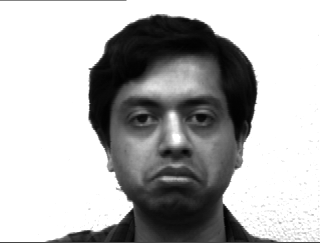

In [14]:
image = Image.open(test_image).convert('L')
image_np = np.array(image, 'uint8')
image_np

In [15]:
image_np.shape

(243, 320)

In [16]:
prediction = lbph_face_classifier.predict(image_np)
prediction

(10, 36.84750735484425)

In [17]:
prediction[0]

10

In [18]:
expected_output = int(os.path.split(test_image)[
                      1].split('.')[0].replace('subject', ''))
expected_output

10

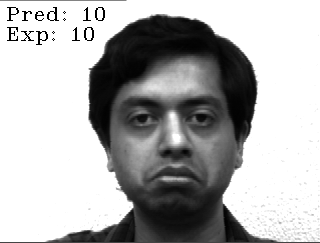

In [19]:
cv2.putText(image_np, 'Pred: ' +
            str(prediction[0]), (5, 20), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 255, 0))

cv2.putText(image_np, 'Exp: ' + str(expected_output), (5, 40),
            cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 255, 0))

cv2_imshow(image_np)

### Evaluating the face classifier


In [20]:
paths = [os.path.join('/content/yalefaces/test', f)
         for f in os.listdir('/content/yalefaces/test')]

predictions = []
expected_outputs = []
for path in paths:
    image = Image.open(path).convert('L')
    image_np = np.array(image, 'uint8')

    prediction, _ = lbph_face_classifier.predict(image_np)
    expected_output = int(os.path.split(path)[1].split('.')[
                          0].replace('subject', ''))

    predictions.append(prediction)
    expected_outputs.append(expected_output)

In [21]:
type(predictions)

list

In [22]:
predictions = np.array(predictions)
expected_outputs = np.array(expected_outputs)

In [23]:
type(predictions)

numpy.ndarray

In [24]:
predictions

array([ 4,  7, 12,  5,  1, 13,  9,  7, 12,  4,  3, 14,  4, 10, 12,  6,  3,
        9,  8,  4, 11,  4,  4, 13, 11, 15,  7, 14, 14,  5])

In [25]:
expected_outputs

array([ 8, 15, 12,  5,  1, 13,  7,  7, 12,  1,  3, 14,  2, 10,  2,  6,  3,
        9,  8,  4, 11,  4, 10, 13, 11, 15,  9,  6, 14,  5])

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(expected_outputs, predictions)

0.7

In [27]:
len(predictions)

30

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(expected_outputs, predictions)
cm

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]])

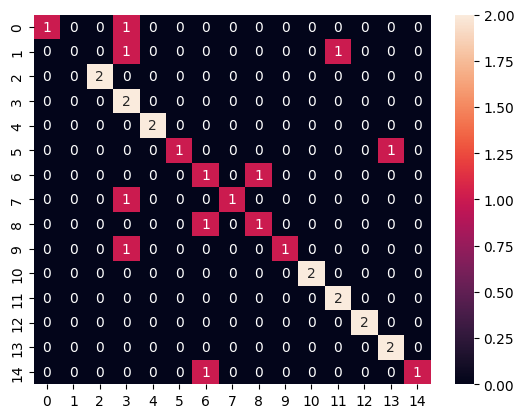

In [29]:
import seaborn

seaborn.heatmap(cm, annot=True)

## Dlib


In [30]:
import cv2
import dlib
from google.colab.patches import cv2_imshow

### Detecting facial points


In [31]:
face_detector = dlib.get_frontal_face_detector()
points_detector = dlib.shape_predictor(
    '/content/drive/MyDrive/Computer-Vision/Weights/shape_predictor_68_face_landmarks.dat')

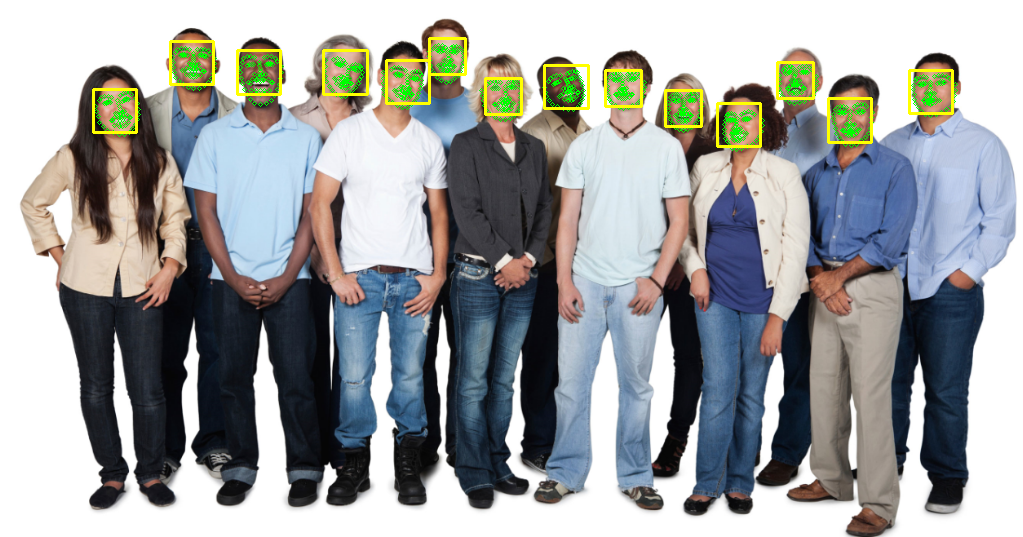

In [32]:
image = cv2.imread('/content/drive/MyDrive/Computer-Vision/Images/people2.jpg')
face_detection = face_detector(image, 1)

for face in face_detection:
    points = points_detector(image, face)

    for point in points.parts():
        cv2.circle(image, (point.x, point.y), 2, (0, 255, 0), 1)

    l, t, r, b = face.left(), face.top(), face.right(), face.bottom()
    cv2.rectangle(image, (l, t), (r, b), (0, 255, 255), 2)

cv2_imshow(image)

## Homework


In [33]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import zipfile

path = '/content/drive/MyDrive/Computer-Vision/Datasets/jones_gabriel.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [35]:
def get_image_data():
    paths = [os.path.join('/content/jones_gabriel', f)
             for f in os.listdir('/content/jones_gabriel')]

    faces = []
    ids = []
    for path in paths:
        image = Image.open(path).convert('L')
        image_np = np.array(image, 'uint8')
        id = int(path.split('.')[1])

        ids.append(id)
        faces.append(image_np)

    return np.array(ids), faces

In [36]:
ids, faces = get_image_data()

In [37]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_classifier.train(faces, ids)
lbph_classifier.write('lbph_classifier.yml')

In [38]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read('/content/lbph_classifier.yml')

In [39]:
image = Image.open('/content/jones_gabriel/person.1.1.jpg')
image.size

(220, 220)

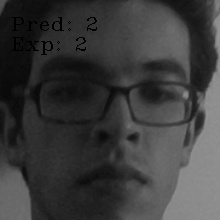

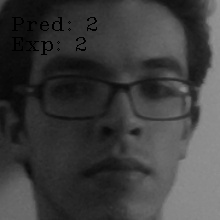

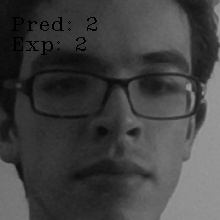

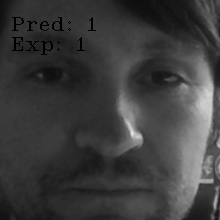

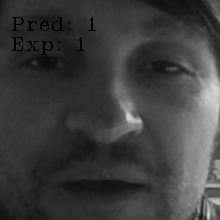

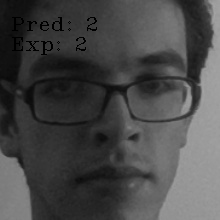

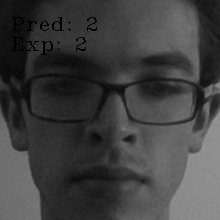

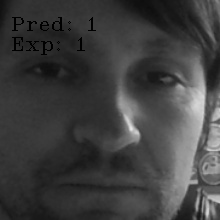

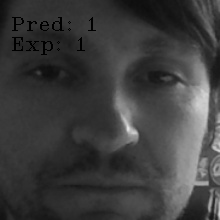

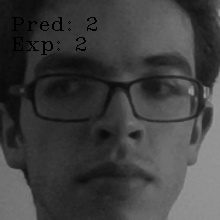

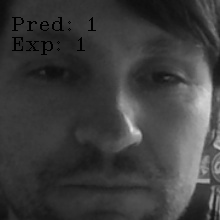

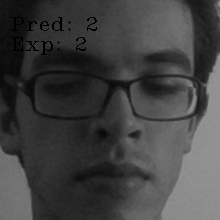

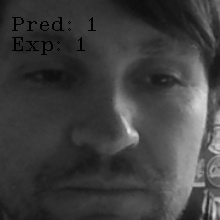

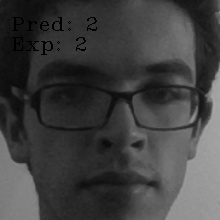

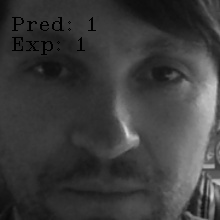

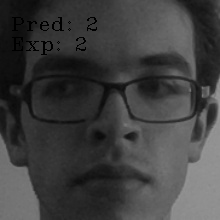

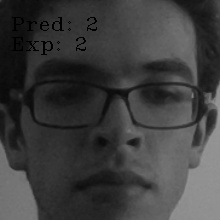

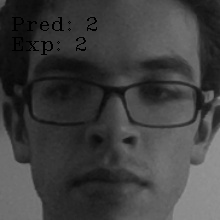

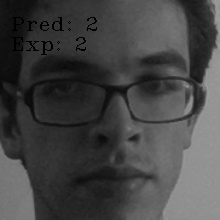

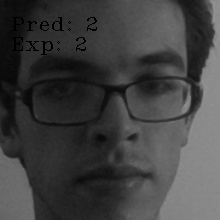

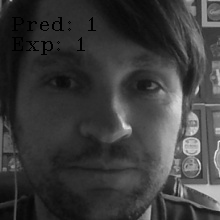

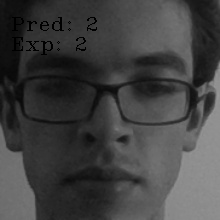

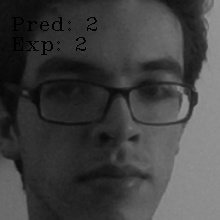

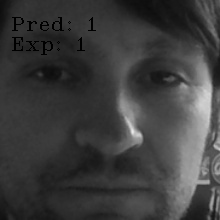

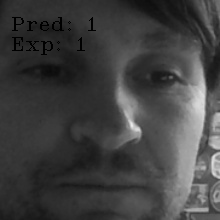

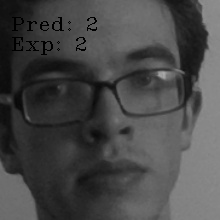

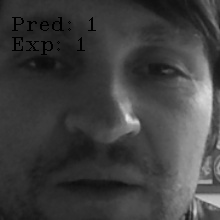

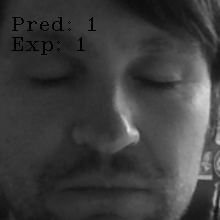

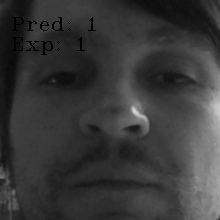

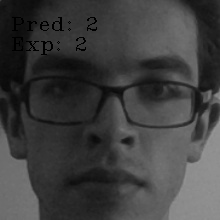

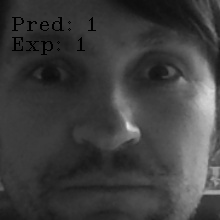

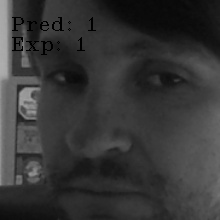

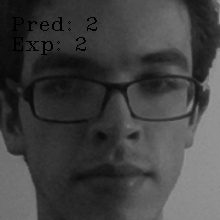

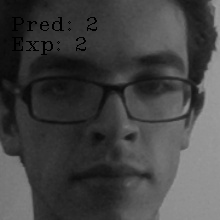

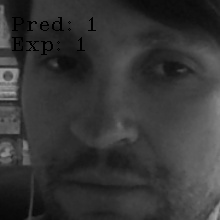

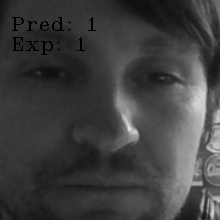

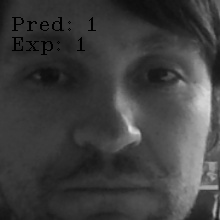

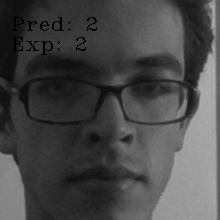

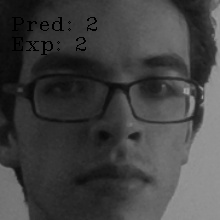

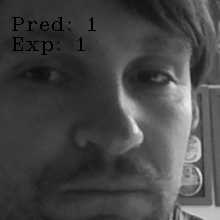

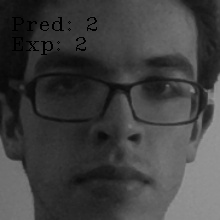

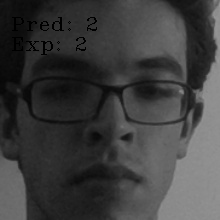

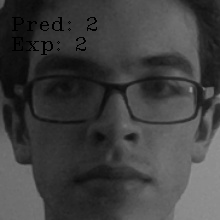

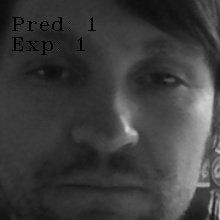

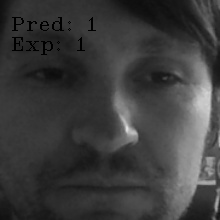

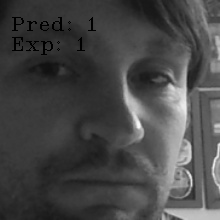

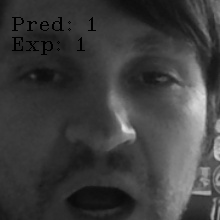

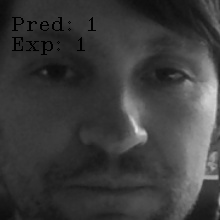

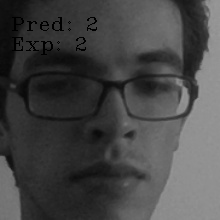

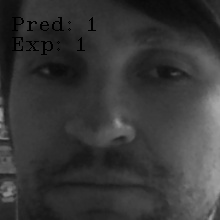

In [40]:
paths = [os.path.join('/content/jones_gabriel', f)
         for f in os.listdir('/content/jones_gabriel')]

for path in paths:
    image = Image.open(path).convert('L')
    image_np = np.array(image, 'uint8')

    prediction, _ = lbph_face_classifier.predict(image_np)
    expected_output = int(path.split('.')[1])

    cv2.putText(image_np, 'Pred: ' + str(prediction), (10, 30),
                cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 255, 0))

    cv2.putText(image_np, 'Exp: ' + str(expected_output), (10, 50),
                cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 255, 0))

    cv2_imshow(image_np)